# 🧬 Projet : Recommandation des Maladies-Gènes par Prédiction des Liens
## 📦 Phase 2 — Collecte et Préparation des Données HPO

---

### 🎯 Objectif de cette phase
- Télécharger les données depuis la base **HPO (Human Phenotype Ontology)**
- Nettoyer et formater les données
- Explorer et visualiser les statistiques du jeu de données
- Préparer les fichiers prêts pour la **Phase 3** (construction du graphe)

---

### 📁 Structure des fichiers produits
```
data/
├── raw/
│   └── genes_to_disease.txt       ← fichier brut HPO
└── processed/
    ├── gene_disease_edges.csv     ← arêtes du graphe (gene_id, disease_id)
    ├── gene_disease_full.csv      ← données complètes
    ├── genes_list.csv             ← liste des gènes uniques
    └── diseases_list.csv          ← liste des maladies uniques
```

## ⚙️ Cellule 0 — Installation des bibliothèques
*(À exécuter une seule fois si tu n'as pas encore installé ces packages)*

In [ ]:
# Décommente et exécute si nécessaire
# !pip install pandas numpy matplotlib seaborn requests

## 📚 Cellule 1 — Importation des bibliothèques

In [1]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style des graphiques
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='Set2')

print('✅ Bibliothèques importées avec succès !')

c:\Users\EL MAHDI MAJDI\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


✅ Bibliothèques importées avec succès !


## 📁 Cellule 2 — Configuration des chemins

In [2]:
# ── Chemins relatifs depuis le dossier notebooks/
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
RAW_DIR  = os.path.join(BASE_DIR, 'data', 'raw')
PROC_DIR = os.path.join(BASE_DIR, 'data', 'processed')

os.makedirs(RAW_DIR,  exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)

RAW_FILE = os.path.join(RAW_DIR, 'genes_to_disease.txt')

print(f'📂 Dossier projet   : {BASE_DIR}')
print(f'📂 Données brutes   : {RAW_DIR}')
print(f'📂 Données traitées : {PROC_DIR}')

📂 Dossier projet   : c:\Users\EL MAHDI MAJDI\Desktop\recommandation-genes-maladies
📂 Données brutes   : c:\Users\EL MAHDI MAJDI\Desktop\recommandation-genes-maladies\data\raw
📂 Données traitées : c:\Users\EL MAHDI MAJDI\Desktop\recommandation-genes-maladies\data\processed


## 🌐 Cellule 3 — Téléchargement des données HPO

> **Source :** [Human Phenotype Ontology](https://hpo.jax.org/)  
> **Fichier :** `genes_to_disease.txt` — associations validées gène ↔ maladie

In [3]:
HPO_URL = 'http://purl.obolibrary.org/obo/hp/hpoa/genes_to_disease.txt'

if os.path.exists(RAW_FILE):
    size_kb = os.path.getsize(RAW_FILE) / 1024
    print(f'✅ Fichier déjà présent ({size_kb:.1f} KB) — téléchargement ignoré')
else:
    print('⏳ Téléchargement en cours...')
    response = requests.get(HPO_URL, timeout=60)
    response.raise_for_status()
    with open(RAW_FILE, 'wb') as f:
        f.write(response.content)
    size_kb = os.path.getsize(RAW_FILE) / 1024
    print(f'✅ Téléchargement terminé ! ({size_kb:.1f} KB)')

print(f'📄 Fichier : {RAW_FILE}')

✅ Fichier déjà présent (1442.8 KB) — téléchargement ignoré
📄 Fichier : c:\Users\EL MAHDI MAJDI\Desktop\recommandation-genes-maladies\data\raw\genes_to_disease.txt


## 👀 Cellule 4 — Chargement et aperçu des données brutes

In [4]:
df_raw = pd.read_csv(RAW_FILE, sep='\t', comment='#', header=0, low_memory=False)

print(f'📊 Dimensions du fichier brut : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes')
print(f'📋 Colonnes : {df_raw.columns.tolist()}\n')

df_raw.head(10)

📊 Dimensions du fichier brut : 15941 lignes × 5 colonnes
📋 Colonnes : ['ncbi_gene_id', 'gene_symbol', 'association_type', 'disease_id', 'source']



,ncbi_gene_id,gene_symbol,association_type,disease_id,source
0,NCBIGene:64170,CARD9,MENDELIAN,OMIM:212050,ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/mim2gene_...
1,NCBIGene:51256,TBC1D7,MENDELIAN,OMIM:248000,ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/mim2gene_...
2,NCBIGene:28981,IFT81,MENDELIAN,OMIM:617895,ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/mim2gene_...
3,NCBIGene:8216,LZTR1,MENDELIAN,OMIM:616564,ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/mim2gene_...
4,NCBIGene:6505,SLC1A1,POLYGENIC,OMIM:615232,ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/mim2gene_...
5,NCBIGene:5949,RBP3,MENDELIAN,OMIM:615233,ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/mim2gene_...
6,NCBIGene:583,BBS2,MENDELIAN,OMIM:616562,ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/mim2gene_...
7,NCBIGene:4750,NEK1,POLYGENIC,OMIM:617892,ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/mim2gene_...
8,NCBIGene:51569,UFM1,MENDELIAN,OMIM:617899,ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/mim2gene_...
9,NCBIGene:392255,GDF6,MENDELIAN,OMIM:617898,ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/mim2gene_...


In [5]:
# Informations générales sur les colonnes
print('ℹ️  Informations sur les colonnes :\n')
df_raw.info()

ℹ️  Informations sur les colonnes :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15941 entries, 0 to 15940
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ncbi_gene_id      15941 non-null  object
 1   gene_symbol       15941 non-null  object
 2   association_type  15941 non-null  object
 3   disease_id        15941 non-null  object
 4   source            15941 non-null  object
dtypes: object(5)
memory usage: 622.8+ KB


In [6]:
# Valeurs manquantes par colonne
missing = df_raw.isnull().sum()
print('🔍 Valeurs manquantes par colonne :')
print(missing.to_string())

🔍 Valeurs manquantes par colonne :
ncbi_gene_id        0
gene_symbol         0
association_type    0
disease_id          0
source              0


## 🧹 Cellule 5 — Nettoyage des données

### Problème à corriger :
- Les identifiants gènes sont au format `NCBIGene:64170` → on extrait juste `64170`
- Les identifiants maladies sont au format `OMIM:212050` → on garde tel quel (bon format)


In [7]:
df = df_raw[['ncbi_gene_id', 'gene_symbol', 'disease_id', 'association_type']].copy()

# ── CORRECTION : extraire l'ID numérique de 'NCBIGene:64170' → '64170'
df['gene_id'] = (df['ncbi_gene_id']
                 .astype(str)
                 .str.replace('NCBIGene:', '', regex=False)
                 .str.strip())

# ── Nettoyage des autres colonnes
df['disease_id']      = df['disease_id'].astype(str).str.strip()
df['gene_symbol']     = df['gene_symbol'].astype(str).str.strip().str.upper()
df['association_type']= df['association_type'].astype(str).str.strip().str.upper()

# ── Supprimer les doublons et valeurs manquantes
avant = len(df)
df.dropna(subset=['gene_id', 'disease_id'], inplace=True)
df.drop_duplicates(subset=['gene_id', 'disease_id'], inplace=True)

# ── Garder uniquement les gene_id numériques valides
df = df[df['gene_id'].str.isnumeric()]
df = df[df['gene_id'] != '0']

# ── Réorganiser les colonnes
df = df[['gene_id', 'gene_symbol', 'disease_id', 'association_type']].reset_index(drop=True)

print(f'✅ Nettoyage terminé !')
print(f'   Lignes avant : {avant}')
print(f'   Lignes après : {len(df)}')
print(f'   Supprimées   : {avant - len(df)}\n')

df.head(10)

✅ Nettoyage terminé !
   Lignes avant : 15941
   Lignes après : 15940
   Supprimées   : 1



,gene_id,gene_symbol,disease_id,association_type
0,64170,CARD9,OMIM:212050,MENDELIAN
1,51256,TBC1D7,OMIM:248000,MENDELIAN
2,28981,IFT81,OMIM:617895,MENDELIAN
3,8216,LZTR1,OMIM:616564,MENDELIAN
4,6505,SLC1A1,OMIM:615232,POLYGENIC
5,5949,RBP3,OMIM:615233,MENDELIAN
6,583,BBS2,OMIM:616562,MENDELIAN
7,4750,NEK1,OMIM:617892,POLYGENIC
8,51569,UFM1,OMIM:617899,MENDELIAN
9,392255,GDF6,OMIM:617898,MENDELIAN


## 📊 Cellule 6 — Statistiques générales

In [8]:
nb_genes    = df['gene_id'].nunique()
nb_maladies = df['disease_id'].nunique()
nb_liens    = len(df)
densite     = nb_liens / (nb_genes * nb_maladies)

# Affichage sous forme de tableau de bord
print('═' * 50)
print('       📈 STATISTIQUES DU GRAPHE BIPARTI')
print('═' * 50)
print(f'  🧬 Gènes uniques          : {nb_genes:>8,}')
print(f'  🦠 Maladies uniques       : {nb_maladies:>8,}')
print(f'  🔗 Associations (arêtes)  : {nb_liens:>8,}')
print(f'  📉 Densité du graphe      : {densite:>8.6f}')
print(f'  📌 Liens max possibles    : {nb_genes * nb_maladies:>8,}')
print('═' * 50)
print()
print('💡 Un graphe avec densité < 0.01 est dit CREUX (sparse).')
print('   C\'est typique des réseaux biologiques réels.')

══════════════════════════════════════════════════
       📈 STATISTIQUES DU GRAPHE BIPARTI
══════════════════════════════════════════════════
  🧬 Gènes uniques          :    5,529
  🦠 Maladies uniques       :   11,026
  🔗 Associations (arêtes)  :   15,940
  📉 Densité du graphe      : 0.000261
  📌 Liens max possibles    : 60,962,754
══════════════════════════════════════════════════

💡 Un graphe avec densité < 0.01 est dit CREUX (sparse).
   C'est typique des réseaux biologiques réels.


## 📊 Cellule 7 — Types d'associations

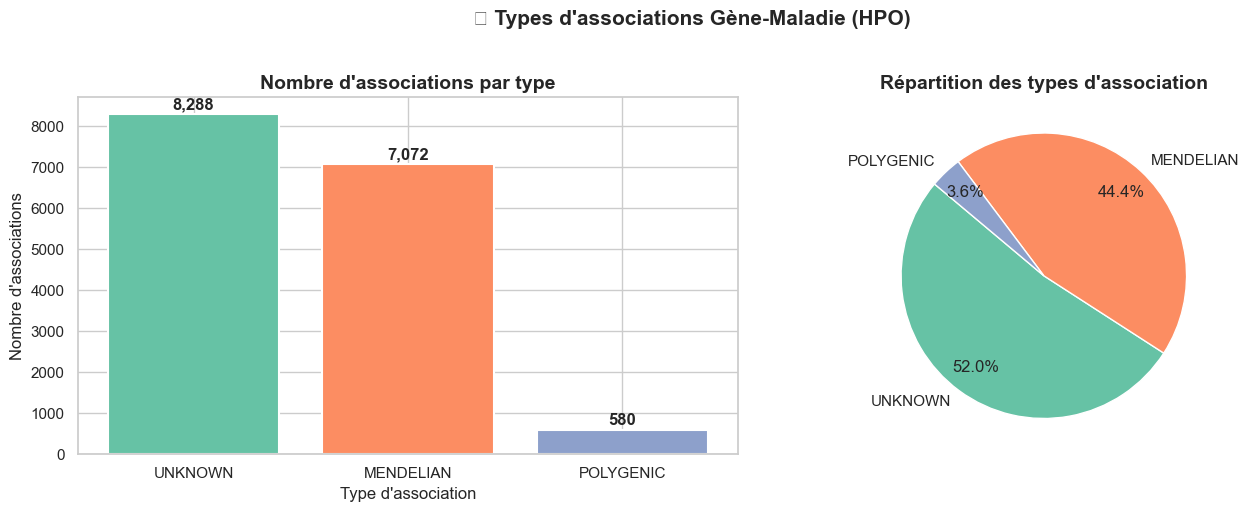


📋 Détail :
   UNKNOWN         :  8,288 associations  (52.0%)
   MENDELIAN       :  7,072 associations  (44.4%)
   POLYGENIC       :    580 associations  (3.6%)


In [9]:
type_counts = df['association_type'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Barplot
colors = sns.color_palette('Set2', len(type_counts))
bars = ax1.bar(type_counts.index, type_counts.values, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Nombre d\'associations par type', fontsize=14, fontweight='bold')
ax1.set_xlabel('Type d\'association')
ax1.set_ylabel('Nombre d\'associations')
for bar, val in zip(bars, type_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}', ha='center', va='bottom', fontweight='bold')

# ── Pie chart
ax2.pie(type_counts.values, labels=type_counts.index,
        autopct='%1.1f%%', colors=colors,
        startangle=140, pctdistance=0.8)
ax2.set_title('Répartition des types d\'association', fontsize=14, fontweight='bold')

plt.suptitle('🔬 Types d\'associations Gène-Maladie (HPO)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n📋 Détail :')
for t, v in type_counts.items():
    pct = v / nb_liens * 100
    print(f'   {t:<15} : {v:>6,} associations  ({pct:.1f}%)')

## 🏆 Cellule 8 — Top 15 des gènes les plus associés

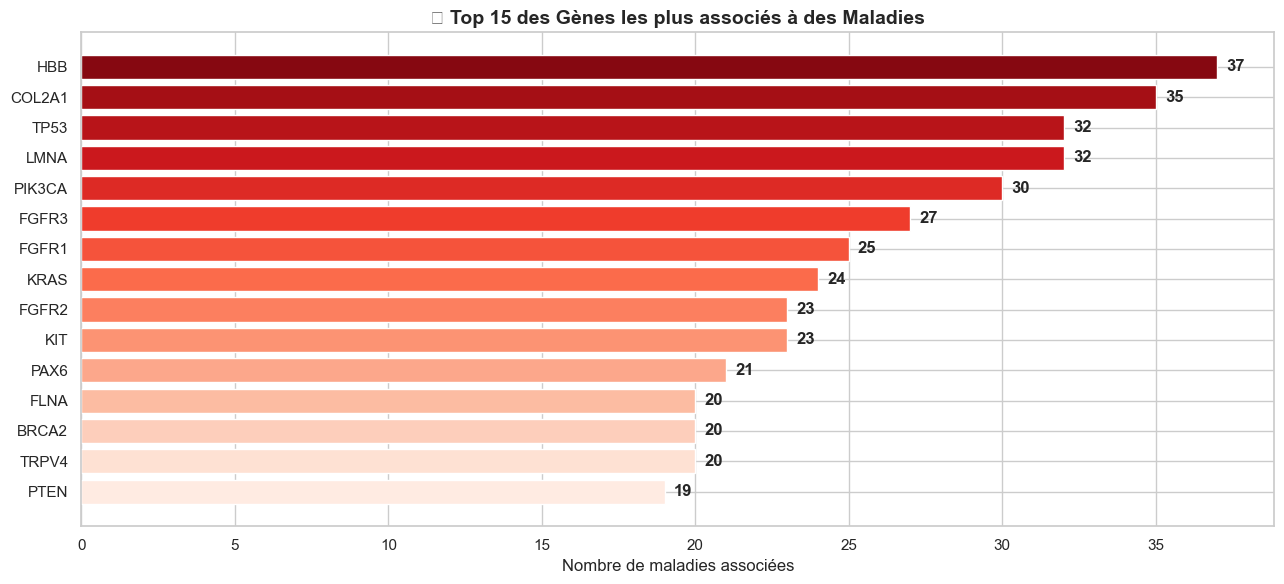


📋 Tableau Top 15 gènes :
   gene_id gene_symbol  nb_maladies
1     3043         HBB           37
2     1280      COL2A1           35
3     7157        TP53           32
4     4000        LMNA           32
5     5290      PIK3CA           30
6     2261       FGFR3           27
7     2260       FGFR1           25
8     3845        KRAS           24
9     2263       FGFR2           23
10    3815         KIT           23
11    5080        PAX6           21
12    2316        FLNA           20
13     675       BRCA2           20
14   59341       TRPV4           20
15    5728        PTEN           19


In [10]:
top_genes = (
    df.groupby(['gene_id', 'gene_symbol'])['disease_id']
      .count()
      .reset_index()
      .rename(columns={'disease_id': 'nb_maladies'})
      .sort_values('nb_maladies', ascending=False)
      .head(15)
)

fig, ax = plt.subplots(figsize=(13, 6))
colors  = sns.color_palette('Reds_r', len(top_genes))
bars    = ax.barh(top_genes['gene_symbol'], top_genes['nb_maladies'],
                  color=colors, edgecolor='white')

for bar, val in zip(bars, top_genes['nb_maladies']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontweight='bold')

ax.set_xlabel('Nombre de maladies associées', fontsize=12)
ax.set_title('🧬 Top 15 des Gènes les plus associés à des Maladies',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\n📋 Tableau Top 15 gènes :')
top_genes.index = range(1, len(top_genes)+1)
print(top_genes.to_string())

## 🏆 Cellule 9 — Top 15 des maladies les plus associées

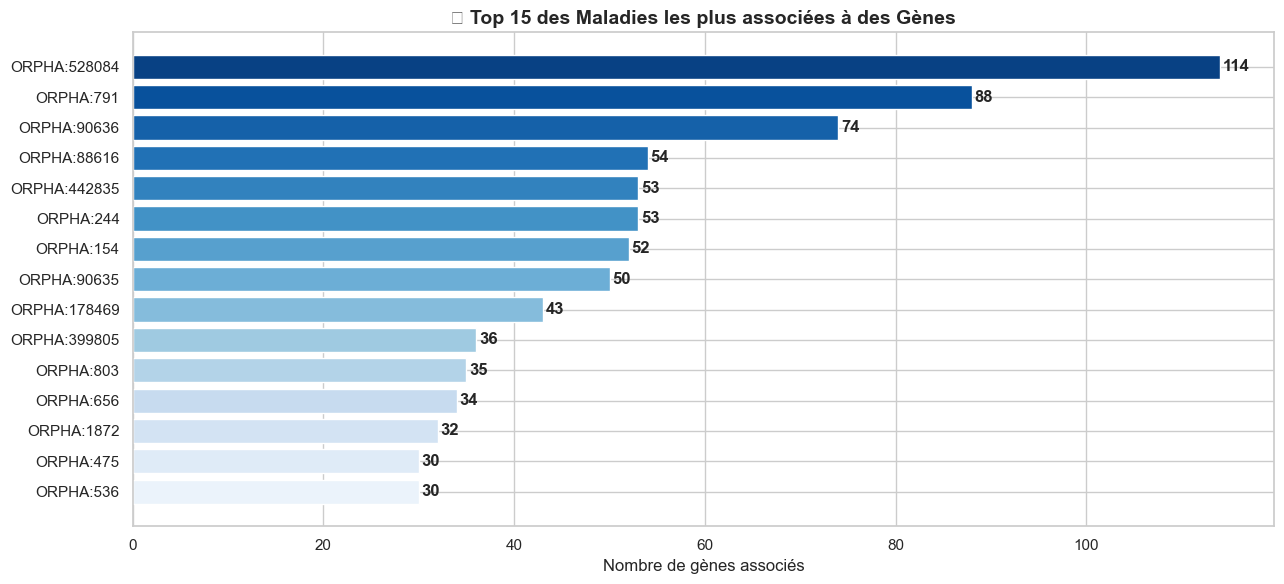


📋 Tableau Top 15 maladies :
      disease_id  nb_genes
1   ORPHA:528084       114
2      ORPHA:791        88
3    ORPHA:90636        74
4    ORPHA:88616        54
5   ORPHA:442835        53
6      ORPHA:244        53
7      ORPHA:154        52
8    ORPHA:90635        50
9   ORPHA:178469        43
10  ORPHA:399805        36
11     ORPHA:803        35
12     ORPHA:656        34
13    ORPHA:1872        32
14     ORPHA:475        30
15     ORPHA:536        30


In [11]:
top_diseases = (
    df.groupby('disease_id')['gene_id']
      .count()
      .reset_index()
      .rename(columns={'gene_id': 'nb_genes'})
      .sort_values('nb_genes', ascending=False)
      .head(15)
)

fig, ax = plt.subplots(figsize=(13, 6))
colors  = sns.color_palette('Blues_r', len(top_diseases))
bars    = ax.barh(top_diseases['disease_id'], top_diseases['nb_genes'],
                  color=colors, edgecolor='white')

for bar, val in zip(bars, top_diseases['nb_genes']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontweight='bold')

ax.set_xlabel('Nombre de gènes associés', fontsize=12)
ax.set_title('🦠 Top 15 des Maladies les plus associées à des Gènes',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\n📋 Tableau Top 15 maladies :')
top_diseases.index = range(1, len(top_diseases)+1)
print(top_diseases.to_string())

## 📉 Cellule 10 — Distribution des degrés (histogrammes)

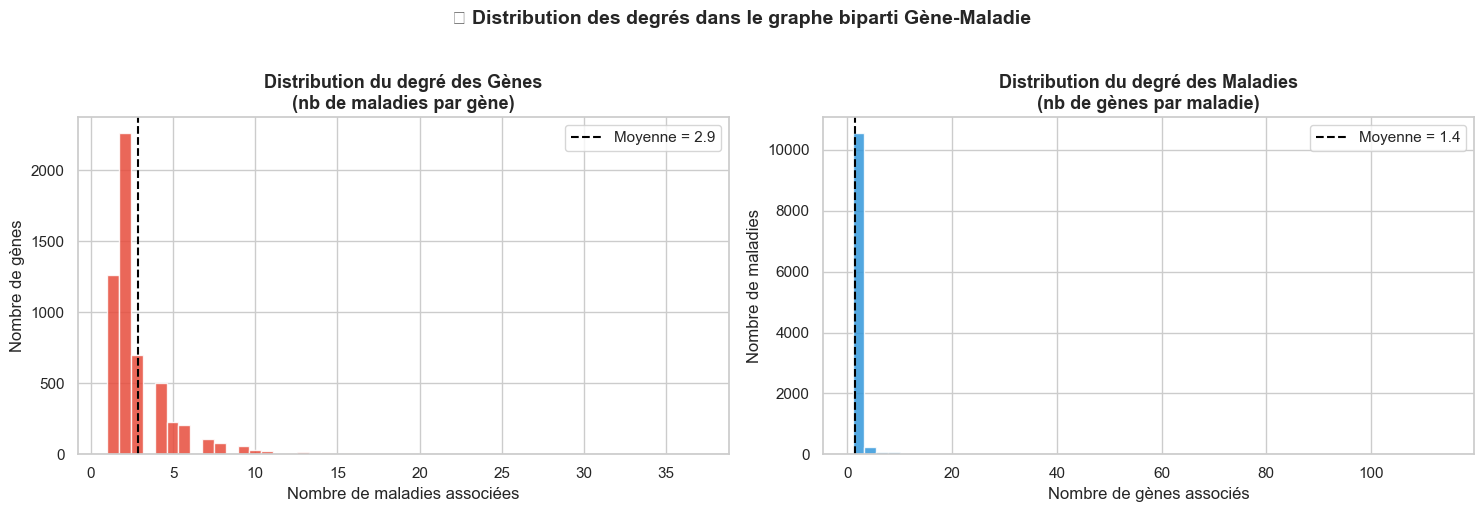


📊 Statistiques des degrés :

  🧬 GÈNES
     Min         : 1
     Max         : 37
     Moyenne     : 2.88
     Médiane     : 2.0

  🦠 MALADIES
     Min         : 1
     Max         : 114
     Moyenne     : 1.45
     Médiane     : 1.0


In [12]:
gene_degrees    = df.groupby('gene_id')['disease_id'].count()
disease_degrees = df.groupby('disease_id')['gene_id'].count()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Distribution des gènes
axes[0].hist(gene_degrees, bins=50, color='#E74C3C', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution du degré des Gènes\n(nb de maladies par gène)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nombre de maladies associées')
axes[0].set_ylabel('Nombre de gènes')
axes[0].axvline(gene_degrees.mean(), color='black', linestyle='--',
                linewidth=1.5, label=f'Moyenne = {gene_degrees.mean():.1f}')
axes[0].legend()

# ── Distribution des maladies
axes[1].hist(disease_degrees, bins=50, color='#3498DB', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution du degré des Maladies\n(nb de gènes par maladie)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de gènes associés')
axes[1].set_ylabel('Nombre de maladies')
axes[1].axvline(disease_degrees.mean(), color='black', linestyle='--',
                linewidth=1.5, label=f'Moyenne = {disease_degrees.mean():.1f}')
axes[1].legend()

plt.suptitle('📉 Distribution des degrés dans le graphe biparti Gène-Maladie',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistiques descriptives
print('\n📊 Statistiques des degrés :')
print(f'\n  🧬 GÈNES')
print(f'     Min         : {gene_degrees.min()}')
print(f'     Max         : {gene_degrees.max()}')
print(f'     Moyenne     : {gene_degrees.mean():.2f}')
print(f'     Médiane     : {gene_degrees.median():.1f}')
print(f'\n  🦠 MALADIES')
print(f'     Min         : {disease_degrees.min()}')
print(f'     Max         : {disease_degrees.max()}')
print(f'     Moyenne     : {disease_degrees.mean():.2f}')
print(f'     Médiane     : {disease_degrees.median():.1f}')

## 🥧 Cellule 11 — Catégories des sources de maladies (OMIM vs autres)

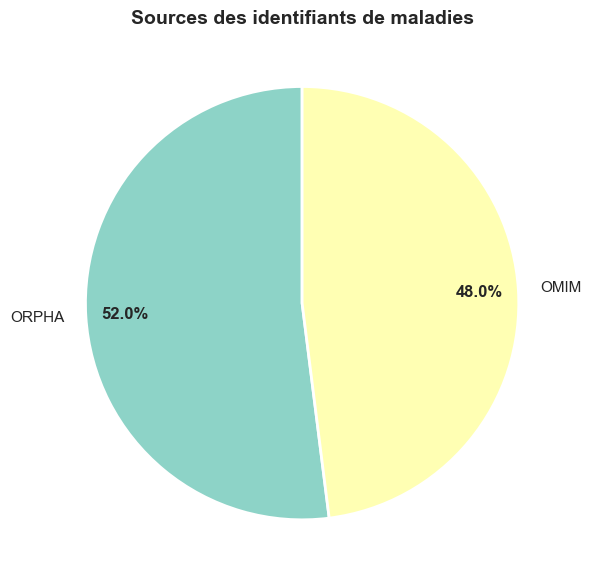


📋 Détail des sources :
   ORPHA      :  8,288 maladies (52.0%)
   OMIM       :  7,652 maladies (48.0%)


In [14]:
# Extraire le préfixe de la source (OMIM, ORPHA, DECIPHER...)
df['disease_source'] = df['disease_id'].str.extract(r'^([A-Z]+):')

source_counts = df['disease_source'].value_counts()

fig, ax = plt.subplots(figsize=(9, 6))
colors  = sns.color_palette('Set3', len(source_counts))
wedges, texts, autotexts = ax.pie(
    source_counts.values,
    labels=source_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for autotext in autotexts:
    autotext.set_fontweight('bold')

ax.set_title('Sources des identifiants de maladies',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📋 Détail des sources :')
for src, cnt in source_counts.items():
    pct = cnt / len(df) * 100
    print(f'   {src:<10} : {cnt:>6,} maladies ({pct:.1f}%)')

## 💾 Cellule 12 — Sauvegarde des données nettoyées

In [15]:
# ── Fichier 1 : Arêtes du graphe (le plus important pour la suite)
edges_file = os.path.join(PROC_DIR, 'gene_disease_edges.csv')
df[['gene_id', 'disease_id']].to_csv(edges_file, index=False)

# ── Fichier 2 : Données complètes
full_file = os.path.join(PROC_DIR, 'gene_disease_full.csv')
df[['gene_id', 'gene_symbol', 'disease_id', 'association_type']].to_csv(full_file, index=False)

# ── Fichier 3 : Liste des gènes
genes_file = os.path.join(PROC_DIR, 'genes_list.csv')
df[['gene_id', 'gene_symbol']].drop_duplicates().to_csv(genes_file, index=False)

# ── Fichier 4 : Liste des maladies
diseases_file = os.path.join(PROC_DIR, 'diseases_list.csv')
df[['disease_id']].drop_duplicates().to_csv(diseases_file, index=False)

print('💾 Fichiers sauvegardés avec succès !')
print()
print(f'  ✅ {edges_file}')
print(f'     → {len(df):,} arêtes (gene_id, disease_id)')
print()
print(f'  ✅ {full_file}')
print(f'     → données complètes avec symboles et types')
print()
print(f'  ✅ {genes_file}')
print(f'     → {df["gene_id"].nunique():,} gènes uniques')
print()
print(f'  ✅ {diseases_file}')
print(f'     → {df["disease_id"].nunique():,} maladies uniques')

💾 Fichiers sauvegardés avec succès !

  ✅ c:\Users\EL MAHDI MAJDI\Desktop\recommandation-genes-maladies\data\processed\gene_disease_edges.csv
     → 15,940 arêtes (gene_id, disease_id)

  ✅ c:\Users\EL MAHDI MAJDI\Desktop\recommandation-genes-maladies\data\processed\gene_disease_full.csv
     → données complètes avec symboles et types

  ✅ c:\Users\EL MAHDI MAJDI\Desktop\recommandation-genes-maladies\data\processed\genes_list.csv
     → 5,529 gènes uniques

  ✅ c:\Users\EL MAHDI MAJDI\Desktop\recommandation-genes-maladies\data\processed\diseases_list.csv
     → 11,026 maladies uniques


## ✅ Cellule 13 — Résumé final de la Phase 2

In [17]:
print('╔══════════════════════════════════════════════════╗')
print('║       ✅ PHASE 2 TERMINÉE AVEC SUCCÈS !          ║')
print('╠══════════════════════════════════════════════════╣')
print(f'║  🧬 Gènes uniques           : {df["gene_id"].nunique():>6,}          ║')
print(f'║  🦠 Maladies uniques        : {df["disease_id"].nunique():>6,}          ║')
print(f'║  🔗 Associations validées   : {len(df):>6,}          ║')
print(f'║  📉 Densité du graphe       : {len(df)/(df["gene_id"].nunique()*df["disease_id"].nunique()):>8.6f}        ║')
print('╠══════════════════════════════════════════════════╣')
print('║  📦 Fichiers produits :                          ║')
print('║     → gene_disease_edges.csv  (arêtes graphe)   ║')
print('║     → gene_disease_full.csv   (données entières)║')
print('║     → genes_list.csv          (liste gènes)     ║')
print('║     → diseases_list.csv       (liste maladies)  ║')
print('╠══════════════════════════════════════════════════╣')
print('║  ➡️  Prochaine étape : Phase 3                   ║')
print('║     Construction du graphe biparti (NetworkX)   ║')
print('╚══════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════╗
║       ✅ PHASE 2 TERMINÉE AVEC SUCCÈS !          ║
╠══════════════════════════════════════════════════╣
║  🧬 Gènes uniques           :  5,529          ║
║  🦠 Maladies uniques        : 11,026          ║
║  🔗 Associations validées   : 15,940          ║
║  📉 Densité du graphe       : 0.000261        ║
╠══════════════════════════════════════════════════╣
║  📦 Fichiers produits :                          ║
║     → gene_disease_edges.csv  (arêtes graphe)   ║
║     → gene_disease_full.csv   (données entières)║
║     → genes_list.csv          (liste gènes)     ║
║     → diseases_list.csv       (liste maladies)  ║
╠══════════════════════════════════════════════════╣
║  ➡️  Prochaine étape : Phase 3                   ║
║     Construction du graphe biparti (NetworkX)   ║
╚══════════════════════════════════════════════════╝
